# 멀티모달 Cross-Attention Fusion
Video × Text × Audio 를 Cross-Attention으로 퓨전하여 감정 이진 분류수행

| 모달 | 파일 | 차원 |
|------|------|------|
| Video | `data/video_features_256.pkl` | 256 |
| Text  | `data/text_features_256(basic+earlystop).pkl` | 256 |
| Audio | `data/audio_feat_hubert_origin.pkl` | 256 |

> **pkl 파일 위치 안내**  
> - Text: sooyeon 브랜치의 `text_features_256(basic+earlystop).pkl` → `data/` 폴더에 복사  
> - Audio: jeein 브랜치의 `audio/audio_feat_hubert_origin.pkl` → `data/` 폴더에 복사

In [1]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


## 1. 피처 로드 & 샘플 정렬

각 pkl은 `{"feat_dict": {sample_key: {"feature": tensor, "label": int}}}` 형식.  
세 모달리티의 **공통 key 교집합**으로 정렬하여 샘플 불일치 문제를 원천 차단한다.

In [ ]:
VIDEO_PKL = 'data/video_features_768.pkl'
TEXT_PKL  = 'data/text_features.pkl'
AUDIO_PKL = 'data/audio_features.pkl'

def load_feat_dict(path):
    """feat_dict 포맷 또는 구버전 포맷 모두 처리."""
    try:
        with open(path, 'rb') as f:
            data = pickle.load(f)
    except Exception:
        data = torch.load(path, map_location='cpu', weights_only=False)

    # ── 신규 포맷: {"feat_dict": {key: {"feature": ..., "label": ...}}} ──
    if isinstance(data, dict) and 'feat_dict' in data:
        return data['feat_dict']

    # ── 구버전 포맷: {"features": tensor, "labels": tensor} or tuple ──
    # index를 key로 변환하여 동일한 dict 구조로 통일
    print(f'  [{path.split("/")[-1]}] 구버전 포맷 감지 → index key로 변환')
    if isinstance(data, dict):
        label_key = next(k for k in data if 'label' in k.lower())
        feat_key  = next(k for k in data if 'label' not in k.lower())
        feats, labels = data[feat_key], data[label_key]
    else:
        feats, labels = data

    if isinstance(feats, torch.Tensor): feats = feats.cpu()
    else: feats = torch.tensor(np.array(feats, dtype=np.float32))
    if isinstance(labels, torch.Tensor): labels = labels.cpu().long()
    else: labels = torch.tensor(np.array(labels), dtype=torch.long)

    return {str(i): {'feature': feats[i], 'label': labels[i].item()} for i in range(len(labels))}

video_dict = load_feat_dict(VIDEO_PKL)
text_dict  = load_feat_dict(TEXT_PKL)
audio_dict = load_feat_dict(AUDIO_PKL)

print(f'로드 완료 — Video: {len(video_dict)}개  Text: {len(text_dict)}개  Audio: {len(audio_dict)}개')

## 2. 공통 key 정렬 & 레이블 진단

In [ ]:
# ── 공통 key 교집합으로 정렬 ──────────────────────────────────────────────────
common_keys = sorted(set(video_dict) & set(text_dict) & set(audio_dict))
assert len(common_keys) > 0, '공통 key 없음! pkl 파일을 확인하세요.'

print(f'Video {len(video_dict)}개 / Text {len(text_dict)}개 / Audio {len(audio_dict)}개')
print(f'공통 key: {len(common_keys)}개  (Video only: {len(set(video_dict)-set(common_keys))}  누락: {len(set(video_dict))-len(common_keys)})')

vid_feats   = torch.stack([video_dict[k]['feature'] for k in common_keys]).float()
text_feats  = torch.stack([text_dict[k]['feature']  for k in common_keys]).float()
audio_feats = torch.stack([audio_dict[k]['feature'] for k in common_keys]).float()

vid_lbl   = torch.tensor([video_dict[k]['label'] for k in common_keys], dtype=torch.long)
text_lbl  = torch.tensor([text_dict[k]['label']  for k in common_keys], dtype=torch.long)
audio_lbl = torch.tensor([audio_dict[k]['label'] for k in common_keys], dtype=torch.long)

print(f'\n피처 shape — Video: {tuple(vid_feats.shape)}  Text: {tuple(text_feats.shape)}  Audio: {tuple(audio_feats.shape)}')

# ── Positive / Negative 분포 비교 ─────────────────────────────────────────────
print(f'\n{"":10} {"Positive(1)":>12} {"Negative(0)":>12}')
print('─' * 36)
for name, lbl in [('Video', vid_lbl), ('Text', text_lbl), ('Audio', audio_lbl)]:
    print(f'{name:<10} {(lbl==1).sum().item():>12,} {(lbl==0).sum().item():>12,}')

# ── 레이블 일치율 ──────────────────────────────────────────────────────────────
vt = (vid_lbl == text_lbl).float().mean().item()
va = (vid_lbl == audio_lbl).float().mean().item()
ta = (text_lbl == audio_lbl).float().mean().item()
print(f'\n레이블 일치율:')
print(f'  Video  vs Text  : {vt*100:.1f}%  {"✅" if vt==1. else "❌"}')
print(f'  Video  vs Audio : {va*100:.1f}%  {"✅" if va==1. else "❌"}')
print(f'  Text   vs Audio : {ta*100:.1f}%  {"✅" if ta==1. else "❌"}')

# ── Ground truth: 가장 많이 일치하는 쪽 ──────────────────────────────────────
if ta == 1.0:
    labels = text_lbl;  gt_src = 'Text = Audio'
elif vt == 1.0:
    labels = vid_lbl;   gt_src = 'Video = Text'
elif va == 1.0:
    labels = vid_lbl;   gt_src = 'Video = Audio'
else:
    labels = text_lbl if ta >= vt else vid_lbl
    gt_src = f'{"Text" if ta>=vt else "Video"} (⚠ 완전 일치 없음)'

print(f'\n→ Ground truth: {gt_src}  |  Positive: {(labels==1).sum().item()}  Negative: {(labels==0).sum().item()}')

In [ ]:
# ── Train / Val / Test 분할 (7:1.5:1.5, stratified) ──────────────────────────
labels_np = labels.numpy()
idx = np.arange(len(labels_np))

tr_idx, te_idx = train_test_split(idx, test_size=0.3,  random_state=SEED, stratify=labels_np)
te_idx, va_idx = train_test_split(te_idx, test_size=0.5, random_state=SEED, stratify=labels_np[te_idx])

print(f'Train: {len(tr_idx)}  Val: {len(va_idx)}  Test: {len(te_idx)}')

def make_loader(idx_arr, shuffle=False):
    v = vid_feats[idx_arr].to(device)
    t = text_feats[idx_arr].to(device)
    a = audio_feats[idx_arr].to(device)
    y = labels[idx_arr].to(device)
    return DataLoader(TensorDataset(v, t, a, y), batch_size=32, shuffle=shuffle)

train_loader = make_loader(tr_idx, shuffle=True)
val_loader   = make_loader(va_idx)
test_loader  = make_loader(te_idx)

## 3. 모델 정의 — Cross-Attention Fusion

```
Video(256) ─┐
Text (256) ─┼─► CrossAttn(V→T,A) + CrossAttn(T→V,A) + CrossAttn(A→V,T) ─► concat(768) ─► MLP ─► 2
Audio(256) ─┘
```

각 모달리티가 나머지 두 모달리티에 대해 **Query → (Key, Value)** Cross-Attention을 수행합니다.

In [5]:
class CrossAttention(nn.Module):
    """단일 Cross-Attention 블록.
    query: (B, D_q)  key/value: (B, N_kv, D_kv)
    out:   (B, D_q)
    """
    def __init__(self, d_query: int, d_kv: int, num_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=d_query, num_heads=num_heads,
            kdim=d_kv, vdim=d_kv,
            batch_first=True, dropout=dropout
        )
        self.norm = nn.LayerNorm(d_query)
        self.ff   = nn.Sequential(
            nn.Linear(d_query, d_query * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_query * 2, d_query),
        )
        self.norm2 = nn.LayerNorm(d_query)

    def forward(self, query, kv):
        """query: (B, D)  kv: (B, 2, D) — 두 모달리티를 sequence로 쌓아서 넣음"""
        q = query.unsqueeze(1)              # (B, 1, D)
        attn_out, _ = self.mha(q, kv, kv)  # (B, 1, D)
        attn_out = attn_out.squeeze(1)      # (B, D)
        x = self.norm(query + attn_out)     # residual
        x = self.norm2(x + self.ff(x))      # FF + residual
        return x


class TriModalCrossAttnFusion(nn.Module):
    """
    Video(v), Text(t), Audio(a) 세 모달리티를 Cross-Attention으로 퓨전.

    각 모달리티가 나머지 두를 attend:
      v' = CrossAttn(Q=v, KV=[t, a])
      t' = CrossAttn(Q=t, KV=[v, a])
      a' = CrossAttn(Q=a, KV=[v, t])

    최종: concat([v', t', a']) → MLP → logits
    """
    def __init__(self, feat_dim: int = 256, num_heads: int = 4,
                 dropout: float = 0.1, num_classes: int = 2):
        super().__init__()
        # 입력 정규화 (각 모달리티의 피처 스케일 통일)
        self.ln_v = nn.LayerNorm(feat_dim)
        self.ln_t = nn.LayerNorm(feat_dim)
        self.ln_a = nn.LayerNorm(feat_dim)

        # Cross-Attention: 각 모달리티 → 나머지 두 모달리티
        self.ca_v = CrossAttention(feat_dim, feat_dim, num_heads, dropout)  # v attends (t,a)
        self.ca_t = CrossAttention(feat_dim, feat_dim, num_heads, dropout)  # t attends (v,a)
        self.ca_a = CrossAttention(feat_dim, feat_dim, num_heads, dropout)  # a attends (v,t)

        # 분류 헤드
        fused_dim = feat_dim * 3  # 256 × 3 = 768
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, v, t, a):
        """v, t, a: (B, 256)"""
        v = self.ln_v(v)
        t = self.ln_t(t)
        a = self.ln_a(a)

        # KV: 두 모달리티를 sequence 차원으로 묶음 (B, 2, 256)
        kv_for_v = torch.stack([t, a], dim=1)  # video가 볼 context
        kv_for_t = torch.stack([v, a], dim=1)  # text가 볼 context
        kv_for_a = torch.stack([v, t], dim=1)  # audio가 볼 context

        v_out = self.ca_v(v, kv_for_v)  # (B, 256)
        t_out = self.ca_t(t, kv_for_t)  # (B, 256)
        a_out = self.ca_a(a, kv_for_a)  # (B, 256)

        fused  = torch.cat([v_out, t_out, a_out], dim=-1)  # (B, 768)
        logits = self.classifier(fused)                     # (B, 2)
        return logits


model = TriModalCrossAttnFusion(feat_dim=256, num_heads=4, dropout=0.2).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n학습 가능한 파라미터: {total_params:,}')

TriModalCrossAttnFusion(
  (ln_v): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (ln_t): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (ln_a): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (ca_v): CrossAttention(
    (mha): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
    (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (ca_t): CrossAttention(
    (mha): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (

## 4. 학습

In [6]:
NUM_EPOCHS   = 50
LR           = 3e-4
PATIENCE     = 10
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience, self.counter, self.best_acc, self.best_state = patience, 0, 0.0, None
    def step(self, val_acc, model):
        if val_acc > self.best_acc + 1e-4:
            self.best_acc  = val_acc
            self.counter   = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

early_stop = EarlyStopping(PATIENCE)
history = {'tr_loss': [], 'va_loss': [], 'tr_acc': [], 'va_acc': []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with (torch.enable_grad() if train else torch.no_grad()):
        for v, t, a, y in loader:
            v, t, a, y = v.to(device), t.to(device), a.to(device), y.to(device)
            logits = model(v, t, a)
            loss   = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

header = f"{'Epoch':>6} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Va Loss':>8} | {'Va Acc':>7}"
print(header); print('-' * len(header))

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    for k, v in zip(['tr_loss','va_loss','tr_acc','va_acc'], [tr_loss, va_loss, tr_acc, va_acc]):
        history[k].append(v)

    stop = early_stop.step(va_acc, model)
    if epoch % 5 == 0 or stop:
        flag = ' ← best' if early_stop.counter == 0 else ''
        print(f"{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | {va_loss:>8.4f} | {va_acc:>7.4f}{flag}")
    if stop:
        print(f"\nEarly Stopping @ epoch {epoch}  (best val_acc={early_stop.best_acc:.4f})")
        break

model.load_state_dict(early_stop.best_state)
print(f'\n최적 모델 복원  (val_acc={early_stop.best_acc:.4f})')

 Epoch |  Tr Loss |  Tr Acc |  Va Loss |  Va Acc
------------------------------------------------
     5 |   0.1323 |  0.9545 |   0.6085 |  0.8500 ← best
    10 |   0.0629 |  0.9792 |   0.8442 |  0.8455
    15 |   0.0146 |  0.9948 |   1.0873 |  0.8318
    16 |   0.0291 |  0.9903 |   1.4358 |  0.8364

Early Stopping @ epoch 16  (best val_acc=0.8545)

최적 모델 복원  (val_acc=0.8545)


## 5. 학습 곡선 시각화

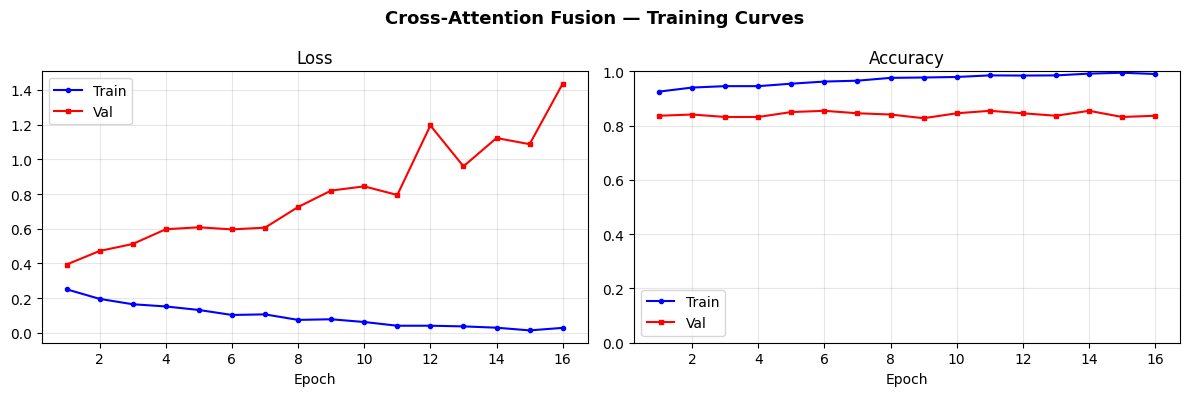

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['tr_loss']) + 1)

axes[0].plot(ep, history['tr_loss'], 'b-o', label='Train', markersize=3)
axes[0].plot(ep, history['va_loss'], 'r-s', label='Val',   markersize=3)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['tr_acc'], 'b-o', label='Train', markersize=3)
axes[1].plot(ep, history['va_acc'], 'r-s', label='Val',   markersize=3)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

plt.suptitle('Cross-Attention Fusion — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fusion_training_curves.png', dpi=150)
plt.show()

## 6. 테스트 성능 평가

In [8]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for v, t, a, y in test_loader:
        v, t, a = v.to(device), t.to(device), a.to(device)
        logits = model(v, t, a)
        preds  = logits.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_targets.extend(y.tolist())

test_acc = accuracy_score(all_targets, all_preds)
test_f1  = f1_score(all_targets, all_preds, average='macro')

print(f'=== Test 결과 ===')
print(f'Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Macro F1 : {test_f1:.4f}')
print()
print(classification_report(all_targets, all_preds, target_names=['Negative(0)', 'Positive(1)']))

=== Test 결과 ===
Accuracy : 0.8591 (85.91%)
Macro F1 : 0.8590

              precision    recall  f1-score   support

 Negative(0)       0.90      0.82      0.86       224
 Positive(1)       0.83      0.90      0.86       216

    accuracy                           0.86       440
   macro avg       0.86      0.86      0.86       440
weighted avg       0.86      0.86      0.86       440



## 7. Confusion Matrix & 모달리티별 기여도 분석

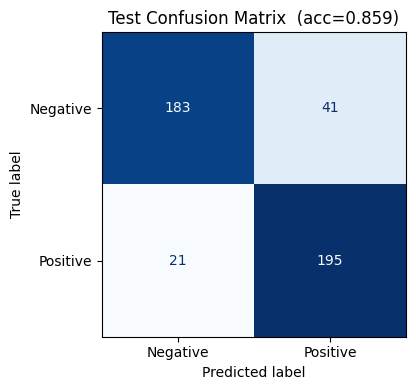

저장: fusion_confusion_matrix.png


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Test Confusion Matrix  (acc={test_acc:.3f})')
plt.tight_layout()
plt.savefig('fusion_confusion_matrix.png', dpi=150)
plt.show()
print('저장: fusion_confusion_matrix.png')

=== Ablation Study (Test Accuracy) ===
  All modalities (full)                    0.8591  █████████████████████████
  Text + Audio (Video masked)              0.8114  ████████████████████████
  Video + Audio (Text masked)              0.5909  █████████████████
  Video + Text (Audio masked)              0.8614  █████████████████████████
  Audio only                               0.5659  ████████████████
  Text only                                0.8455  █████████████████████████
  Video only                               0.5523  ████████████████


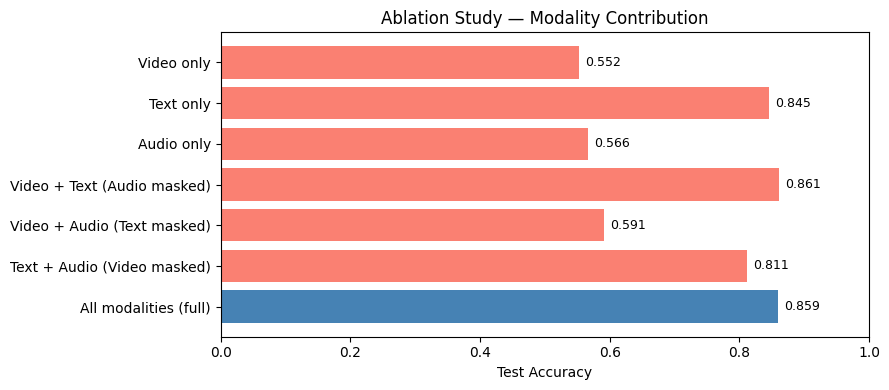

저장: fusion_ablation.png


In [10]:
# ── 모달리티 ablation (단일 모달리티 제로-마스킹) ───────────────────────────────
def eval_with_mask(loader, mask_v=False, mask_t=False, mask_a=False):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for v, t, a, y in loader:
            v, t, a = v.to(device), t.to(device), a.to(device)
            if mask_v: v = torch.zeros_like(v)
            if mask_t: t = torch.zeros_like(t)
            if mask_a: a = torch.zeros_like(a)
            logits = model(v, t, a)
            preds.extend(logits.argmax(1).cpu().tolist())
            targets.extend(y.tolist())
    return accuracy_score(targets, preds)

ablation = {
    'All modalities (full)':       eval_with_mask(test_loader),
    'Text + Audio (Video masked)': eval_with_mask(test_loader, mask_v=True),
    'Video + Audio (Text masked)': eval_with_mask(test_loader, mask_t=True),
    'Video + Text (Audio masked)': eval_with_mask(test_loader, mask_a=True),
    'Audio only':                  eval_with_mask(test_loader, mask_v=True, mask_t=True),
    'Text only':                   eval_with_mask(test_loader, mask_v=True, mask_a=True),
    'Video only':                  eval_with_mask(test_loader, mask_t=True, mask_a=True),
}

print('=== Ablation Study (Test Accuracy) ===')
for name, acc in ablation.items():
    bar = '█' * int(acc * 30)
    print(f'  {name:<40} {acc:.4f}  {bar}')

# 시각화
fig, ax = plt.subplots(figsize=(9, 4))
names = list(ablation.keys())
accs  = list(ablation.values())
colors = ['steelblue' if i == 0 else 'salmon' for i in range(len(names))]
bars = ax.barh(names, accs, color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel('Test Accuracy')
ax.set_title('Ablation Study — Modality Contribution')
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fusion_ablation.png', dpi=150)
plt.show()
print('저장: fusion_ablation.png')

## 8. 모델 저장

In [11]:
torch.save({
    'model_state_dict': model.state_dict(),
    'test_acc':  test_acc,
    'test_f1':   test_f1,
    'val_acc':   early_stop.best_acc,
    'config': {'feat_dim': 256, 'num_heads': 4, 'dropout': 0.2},
}, 'cross_attn_fusion_best.pt')

print('모델 저장 완료: cross_attn_fusion_best.pt')
print(f'\n최종 성능 요약')
print(f'  Val  Accuracy : {early_stop.best_acc:.4f}')
print(f'  Test Accuracy : {test_acc:.4f}')
print(f'  Test Macro F1 : {test_f1:.4f}')

모델 저장 완료: cross_attn_fusion_best.pt

최종 성능 요약
  Val  Accuracy : 0.8545
  Test Accuracy : 0.8591
  Test Macro F1 : 0.8590
